Este es el modelado, la idea es usar un modelo basado en árboles para saber las variables que influyen más en el desarme de una tarima.

El dataset que se va a usar es que salió como resultado del notebook "02_vista_tarimas" (el dataset ya está limpio y preprocesado)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data=pd.read_csv(r'D:/DocumentsD/4to_semestre/Analisis de Ciencia de Datos/Reto-Ternium/outputs/02_vista_tarimas.csv')

In [10]:
# Imputar NaN en features de violacion con 0 (sin match = no viola regla conocida)
data['viola_max_cintas'] = data['viola_max_cintas'].fillna(0)
data['viola_max_peso'] = data['viola_max_peso'].fillna(0)

In [11]:
data.head()

,ARMA_TARIMA,DESARMA_TARIMA,n_cintas,peso_total,n_materiales_padre,n_consignatarios,diff_diametro,tipo_embalaje,ancho_max,n_numeros_parte,viola_max_cintas,viola_max_peso
0,TAR343176-APT,1,5,7.750,1,1,0.077767,OJO_HORIZONTAL,198.13,1,1.0,0.0
1,TAR343177-APT,1,5,8.250,1,1,0.080881,OJO_HORIZONTAL,198.13,1,1.0,1.0
2,TAR351789-EMBSL1_JUV,1,1,1.897,1,1,0.000000,OJO_HORIZONTAL,233.61,1,0.0,0.0
3,TAR366769-EMBSL2_JUV,1,1,0.482,1,1,0.000000,OJO_VERTICAL,160.02,1,0.0,0.0
4,TAR366783-SLT4_JUV,1,1,1.377,1,1,0.000000,OJO_HORIZONTAL,197.99,1,0.0,0.0


In [12]:
data=pd.get_dummies(data,columns=['tipo_embalaje'],drop_first=True,dtype=int)

In [13]:
data.head()

,ARMA_TARIMA,DESARMA_TARIMA,n_cintas,peso_total,n_materiales_padre,n_consignatarios,diff_diametro,ancho_max,n_numeros_parte,viola_max_cintas,viola_max_peso,tipo_embalaje_OJO_VERTICAL
0,TAR343176-APT,1,5,7.750,1,1,0.077767,198.13,1,1.0,0.0,0
1,TAR343177-APT,1,5,8.250,1,1,0.080881,198.13,1,1.0,1.0,0
2,TAR351789-EMBSL1_JUV,1,1,1.897,1,1,0.000000,233.61,1,0.0,0.0,0
3,TAR366769-EMBSL2_JUV,1,1,0.482,1,1,0.000000,160.02,1,0.0,0.0,1
4,TAR366783-SLT4_JUV,1,1,1.377,1,1,0.000000,197.99,1,0.0,0.0,0


In [14]:
tipo_cols = [c for c in data.columns if c.startswith('tipo_embalaje_')]
data[tipo_cols] = data[tipo_cols].astype(int)

In [15]:
data.head()

,ARMA_TARIMA,DESARMA_TARIMA,n_cintas,peso_total,n_materiales_padre,n_consignatarios,diff_diametro,ancho_max,n_numeros_parte,viola_max_cintas,viola_max_peso,tipo_embalaje_OJO_VERTICAL
0,TAR343176-APT,1,5,7.750,1,1,0.077767,198.13,1,1.0,0.0,0
1,TAR343177-APT,1,5,8.250,1,1,0.080881,198.13,1,1.0,1.0,0
2,TAR351789-EMBSL1_JUV,1,1,1.897,1,1,0.000000,233.61,1,0.0,0.0,0
3,TAR366769-EMBSL2_JUV,1,1,0.482,1,1,0.000000,160.02,1,0.0,0.0,1
4,TAR366783-SLT4_JUV,1,1,1.377,1,1,0.000000,197.99,1,0.0,0.0,0


In [16]:
data.shape

(9817, 12)

In [17]:
data.drop(columns=['ARMA_TARIMA'],inplace=True)
data.shape

(9817, 11)

In [18]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
DESARMA_TARIMA,9817.0,0.206682,0.404946,0.000,0.00,0.000,0.000,1.000000
n_cintas,9817.0,2.831211,1.467570,1.000,2.00,2.000,3.000,16.000000
peso_total,9817.0,6.819930,5.865040,0.124,2.25,3.812,10.098,40.596000
n_materiales_padre,9817.0,1.006417,0.096070,1.000,1.00,1.000,1.000,4.000000
n_consignatarios,9817.0,1.005195,0.071893,1.000,1.00,1.000,1.000,2.000000
diff_diametro,9817.0,0.639002,5.829872,0.000,0.00,0.000,0.000,228.598871
ancho_max,9817.0,255.993376,147.376189,37.450,123.55,230.680,384.250,596.980000
n_numeros_parte,9817.0,1.028828,0.182474,1.000,1.00,1.000,1.000,3.000000
viola_max_cintas,9817.0,0.028522,0.166467,0.000,0.00,0.000,0.000,1.000000
viola_max_peso,9817.0,0.030661,0.172407,0.000,0.00,0.000,0.000,1.000000


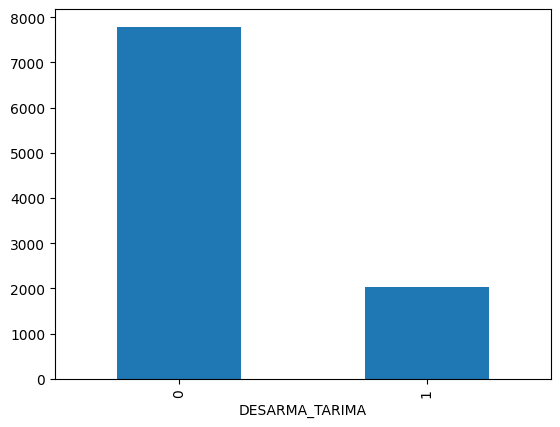

Casos de desarme: 20.67%


In [19]:
data['DESARMA_TARIMA'].value_counts().plot(kind='bar')
plt.show()
print(f"Casos de desarme: {round((data['DESARMA_TARIMA'].value_counts()[1] / data.shape[0])* 100,2) }%")

Primero empezaremos con un modelo base, el que elegimos va a ser un árbol de decisión para después probar con un random forest

# Árbol de decisión

In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    balanced_accuracy_score
)
RANDOM_STATE = 42

In [21]:
x=data.drop('DESARMA_TARIMA',axis=1)
y=data['DESARMA_TARIMA']

In [22]:
X_temp, x_test, y_temp, y_test = train_test_split(
    x, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

x_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train:", x_train.shape)
print("Validation:", X_val.shape)
print("Test:", x_test.shape)
parametros={
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20,37],
    'min_samples_split': [2, 5, 10,15],
    'min_samples_leaf': [1, 2, 4,8],
    'max_features': [None,'sqrt', 'log2'],
}

grid_srch=GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),param_grid=parametros,cv=5,return_train_score=True)

Train: (5889, 10)
Validation: (1964, 10)
Test: (1964, 10)


In [23]:
grid_srch.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [24]:
print("Mejores hiperparámetros\n", grid_srch.best_params_)

Mejores hiperparámetros
 {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [25]:
modelo_base=grid_srch.best_estimator_

vamos a ver que tal se comporta el modelo y que resultados tuvo

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1558
           1       0.86      0.40      0.55       406

    accuracy                           0.86      1964
   macro avg       0.86      0.69      0.73      1964
weighted avg       0.86      0.86      0.84      1964



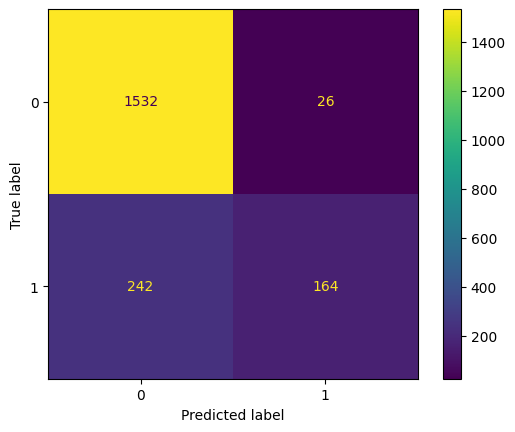

In [26]:
y_pred=modelo_base.predict(x_test)
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()
print(classification_report(y_test,y_pred))

<Figure size 640x480 with 0 Axes>

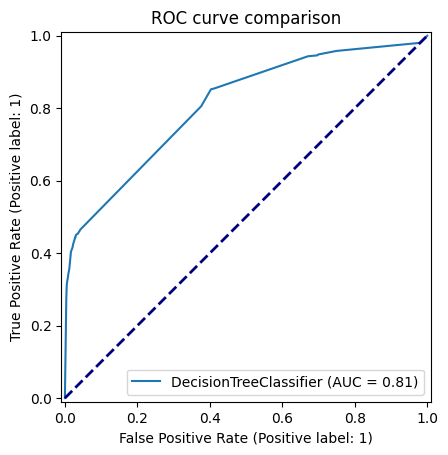

In [27]:
from sklearn.metrics import RocCurveDisplay

plt.figure()
lw = 2
disp = RocCurveDisplay.from_estimator(modelo_base, x_test, y_test)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.title("ROC curve comparison")
plt.legend(loc="lower right")
plt.show()

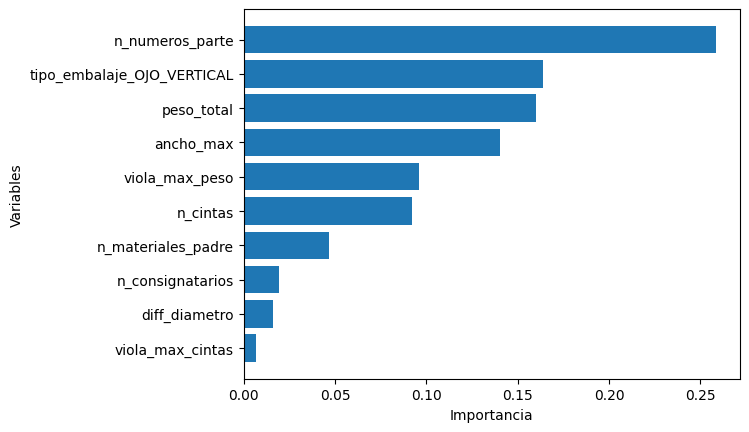

In [28]:
importancia=modelo_base.feature_importances_
importancia=pd.DataFrame(importancia,index=x.columns,columns=['importancia']).sort_values('importancia',ascending=True)
plt.barh(importancia.index,importancia['importancia'])
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.show()

Podemos ver que el modelo tienen un desempeño muy malo para identificar desarmes, es por eso que vamos a subir el costo por mala clasificación de los positivos

In [29]:
from sklearn.pipeline import make_pipeline


In [30]:

def evaluate_threshold(y_true, y_prob, threshold=0.5, cost_fp=1, cost_fn=1):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        "threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "cost_fp": cost_fp,
        "cost_fn": cost_fn,
        "total_cost": fp * cost_fp + fn * cost_fn
    }

    return metrics

def threshold_table(y_true, y_prob, thresholds, cost_fp=1, cost_fn=1):
    rows = [
        evaluate_threshold(
            y_true=y_true,
            y_prob=y_prob,
            threshold=t,
            cost_fp=cost_fp,
            cost_fn=cost_fn
        )
        for t in thresholds
    ]

    return pd.DataFrame(rows)

def plot_confusion(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm)
    plt.title(f"Matriz de confusión | threshold={threshold:.2f}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

    plt.colorbar()
    plt.tight_layout()
    plt.show()

def plot_roc_pr(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    roc_auc = roc_auc_score(y_true, y_prob)
    avg_precision = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Referencia aleatoria")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Recall")
    plt.title("Curva ROC")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f"Average Precision = {avg_precision:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Curva Precision-Recall")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_threshold_tradeoff(table, title="Métricas por threshold"):
    plt.figure(figsize=(7, 4))
    plt.plot(table["threshold"], table["precision"], marker="o", label="precision")
    plt.plot(table["threshold"], table["recall"], marker="o", label="recall")
    plt.plot(table["threshold"], table["f1"], marker="o", label="f1")
    plt.xlabel("Threshold")
    plt.ylabel("Métrica")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_cost_by_threshold(table, title="Costo por threshold"):
    plt.figure(figsize=(7, 4))
    plt.plot(table["threshold"], table["total_cost"], marker="o")
    plt.xlabel("Threshold")
    plt.ylabel("Costo total")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [31]:
y_prob = modelo_base.predict_proba(x_test)[:, 1]

In [32]:
print("Tamaño de prueba:", len(y_test))
print("Proporción de clase positiva en prueba:", y_test.mean().round(3))
print("Primeras probabilidades predichas:")
pd.DataFrame({
    "y_real": y_test[:10],
    "prob_evento": np.round(y_prob[:10], 3)
})


Tamaño de prueba: 1964
Proporción de clase positiva en prueba: 0.207
Primeras probabilidades predichas:


,y_real,prob_evento
878,0,0.021
2769,0,0.068
5469,0,0.068
9384,0,0.222
5927,1,1.000
2320,0,0.222
9471,0,0.222
7133,0,0.021
1214,0,0.222
573,1,1.000


In [33]:
thresholds = np.array([0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90])

table_default_cost = threshold_table(
    y_true=y_test,
    y_prob=y_prob,
    thresholds=thresholds,
    cost_fp=1,
    cost_fn=1
)

table_default_cost[[
    "threshold", "TN", "FP", "FN", "TP",
    "accuracy", "precision", "recall", "f1"
]].round(3)


,threshold,TN,FP,FN,TP,accuracy,precision,recall,f1
0,0.1,915,643,59,347,0.643,0.351,0.855,0.497
1,0.2,972,586,79,327,0.661,0.358,0.805,0.496
2,0.3,1504,54,222,184,0.859,0.773,0.453,0.571
3,0.4,1513,45,226,180,0.862,0.800,0.443,0.571
4,0.5,1525,33,237,169,0.863,0.837,0.416,0.556
5,0.6,1544,14,268,138,0.856,0.908,0.340,0.495
6,0.7,1544,14,269,137,0.856,0.907,0.337,0.492
7,0.8,1550,8,279,127,0.854,0.941,0.313,0.470
8,0.9,1552,6,294,112,0.847,0.949,0.276,0.427


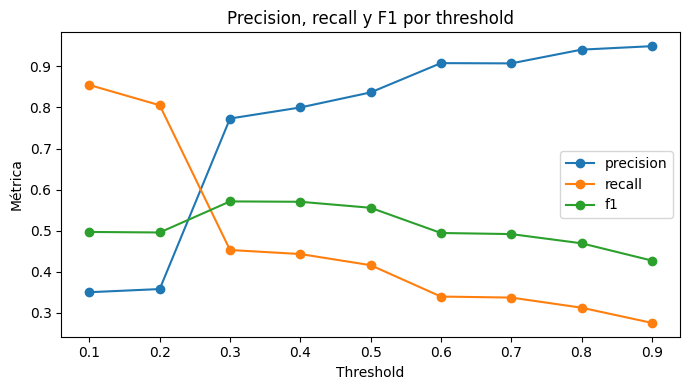

In [34]:
plot_threshold_tradeoff(table_default_cost, title='Precision, recall y F1 por threshold')

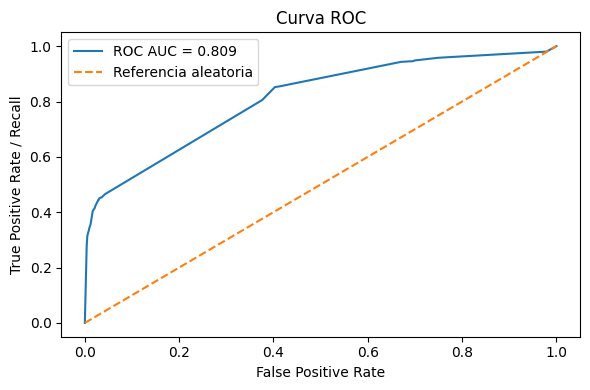

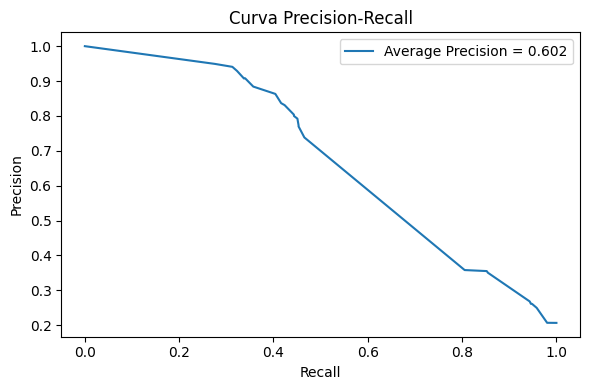

In [35]:
plot_roc_pr(y_test, y_prob)

In [36]:
funcion_costo = threshold_table(
    y_true=y_test,
    y_prob=y_prob,
    thresholds=thresholds,
    cost_fp=1,
    cost_fn=4
)

funcion_costo[[
    "threshold", "FP", "FN", "precision", "recall", "f1", "total_cost"
]].round(3)


,threshold,FP,FN,precision,recall,f1,total_cost
0,0.1,643,59,0.351,0.855,0.497,879
1,0.2,586,79,0.358,0.805,0.496,902
2,0.3,54,222,0.773,0.453,0.571,942
3,0.4,45,226,0.800,0.443,0.571,949
4,0.5,33,237,0.837,0.416,0.556,981
5,0.6,14,268,0.908,0.340,0.495,1086
6,0.7,14,269,0.907,0.337,0.492,1090
7,0.8,8,279,0.941,0.313,0.470,1124
8,0.9,6,294,0.949,0.276,0.427,1182


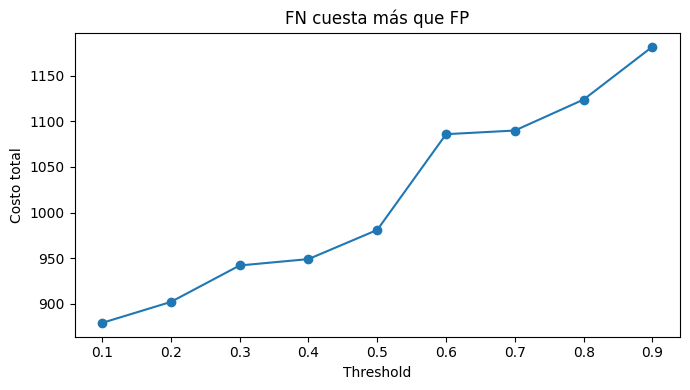

In [37]:
plot_cost_by_threshold(funcion_costo, title='FN cuesta más que FP')

In [38]:
y_val_pred=modelo_base.predict(X_val)
y_train_pred=modelo_base.predict(x_train)

train_acc = f1_score(y_train, y_train_pred)
val_acc = f1_score(y_val, y_val_pred)

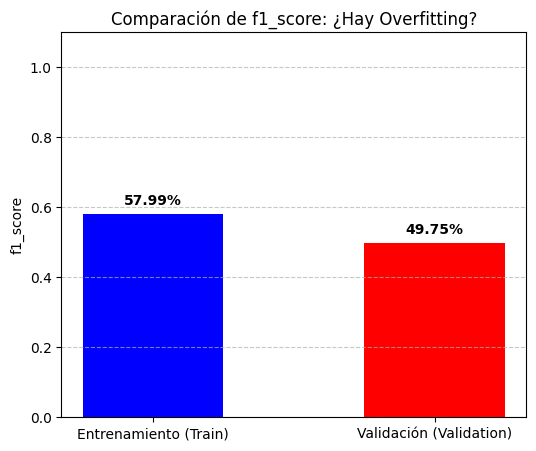

Brecha de rendimiento: 8.24%
La brecha es menor o igual al 10%


In [39]:
categorias = ["Entrenamiento (Train)", "Validación (Validation)"]
valores = [train_acc, val_acc]

plt.figure(figsize=(6, 5))
barras = plt.bar(categorias, valores, color=['blue', "red"], width=0.5)

for barra in barras:
    yval = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        yval + 0.02,
        f"{yval*100:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.ylabel("f1_score")
plt.title("Comparación de f1_score: ¿Hay Overfitting?")
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print(f"Brecha de rendimiento: {(train_acc - val_acc)*100:.2f}%")
if train_acc - val_acc > 0.10:
    print("Hay una brecha mayor al 10%")
else:
    print("La brecha es menor o igual al 10%")

In [40]:
from sklearn.calibration import calibration_curve

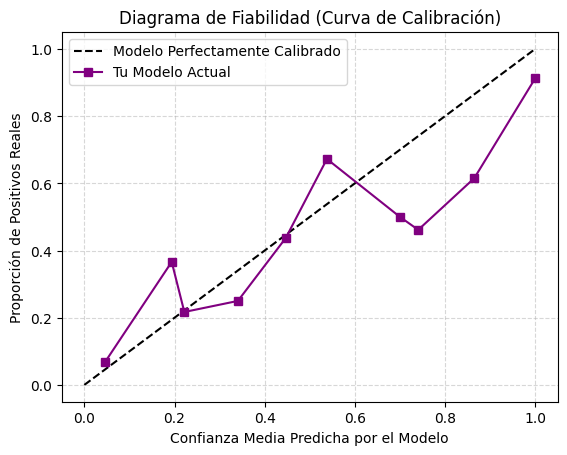

In [41]:
y_prob_val=modelo_base.predict_proba(X_val)[:,1]
prob_verdadera, prob_predicha = calibration_curve(
    y_val, y_prob_val, n_bins=10, strategy="uniform"
)
plt.plot([0, 1], [0, 1], "k--", label="Modelo Perfectamente Calibrado")

plt.plot(
    prob_predicha,
    prob_verdadera,
    "s-",
    color="purple",
    label="Tu Modelo Actual",
)

plt.title("Diagrama de Fiabilidad (Curva de Calibración)")
plt.xlabel("Confianza Media Predicha por el Modelo")
plt.ylabel("Proporción de Positivos Reales")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Podemos ver que aunque escojamos los mejores parametros, bajemos el treshold o escojamos el modelo con base a el costo del mismo los resultados que da son pobres.

El siguiente paso va a ser probar con un random forest, el objetivo es que el modelo como mínimo sea mejor que el modelo base (el árbol de desición)

#Random forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
X_temp, x_test, y_temp, y_test = train_test_split(
    x, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

x_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train:", x_train.shape)
print("Validation:", X_val.shape)
print("Test:", x_test.shape)

parametros = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15,],
    'min_samples_split': [4, 6, 8],
    'min_samples_leaf': [6, 10],
    'max_features': ['sqrt'],
    'bootstrap': [True],
    'class_weight': ['balanced', 'balanced_subsample']
}

grid_srch=GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=parametros,return_train_score=True,n_jobs=-1,scoring='f1',)

Train: (5889, 10)
Validation: (1964, 10)
Test: (1964, 10)


In [44]:
grid_srch.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [10, 15], 'max_features': ['sqrt'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [45]:
print("Mejores hiperparámetros\n", grid_srch.best_params_)

Mejores hiperparámetros
 {'bootstrap': True, 'class_weight': 'balanced_subsample', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 4, 'n_estimators': 150}


In [46]:
modelo=grid_srch.best_estimator_

              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1558
           1       0.46      0.72      0.56       406

    accuracy                           0.77      1964
   macro avg       0.69      0.75      0.70      1964
weighted avg       0.82      0.77      0.79      1964



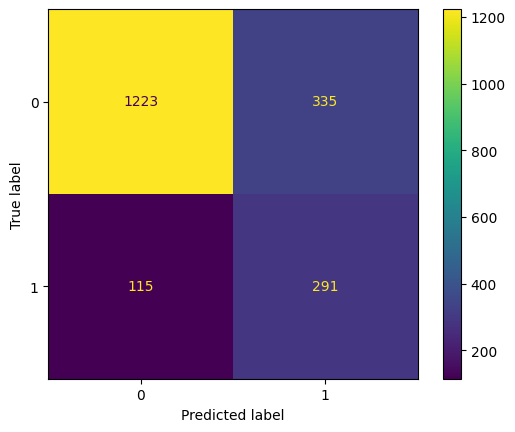

In [47]:
y_pred=modelo.predict(x_test)
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()
print(classification_report(y_test,y_pred))

<Figure size 640x480 with 0 Axes>

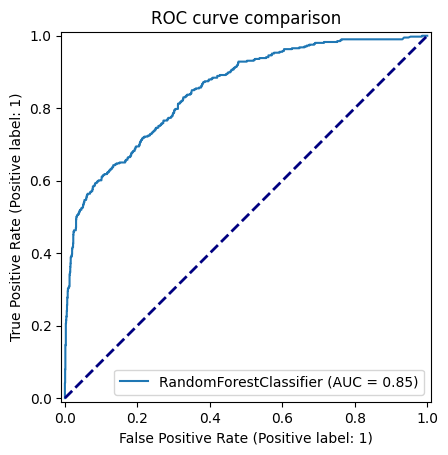

In [48]:
from sklearn.metrics import RocCurveDisplay

plt.figure()
lw = 2
disp = RocCurveDisplay.from_estimator(modelo, x_test, y_test)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.title("ROC curve comparison")
plt.legend(loc="lower right")
plt.show()

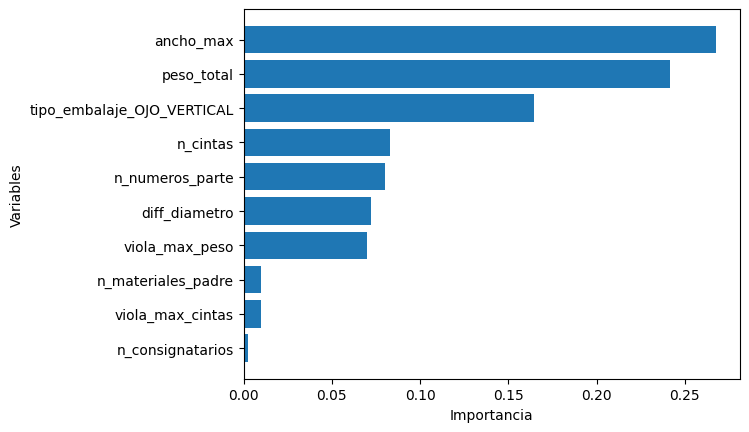

In [49]:
importancia=modelo.feature_importances_
importancia=pd.DataFrame(importancia,index=x.columns,columns=['importancia']).sort_values('importancia',ascending=True)
plt.barh(importancia.index,importancia['importancia'])
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.show()

In [50]:
y_prob = modelo.predict_proba(x_test)[:, 1]

In [51]:
print("Tamaño de prueba:", len(y_test))
print("Proporción de clase positiva en prueba:", y_test.mean().round(3))
print("Primeras probabilidades predichas:")
pd.DataFrame({
    "y_real": y_test[:10],
    "prob_evento": np.round(y_prob[:10], 3)
})


Tamaño de prueba: 1964
Proporción de clase positiva en prueba: 0.207
Primeras probabilidades predichas:


,y_real,prob_evento
878,0,0.101
2769,0,0.091
5469,0,0.302
9384,0,0.452
5927,1,0.750
2320,0,0.548
9471,0,0.502
7133,0,0.098
1214,0,0.450
573,1,0.953


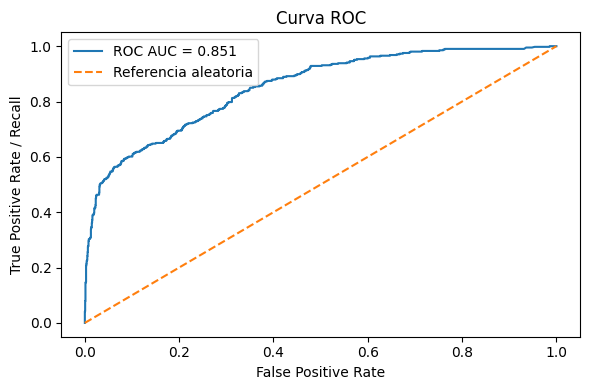

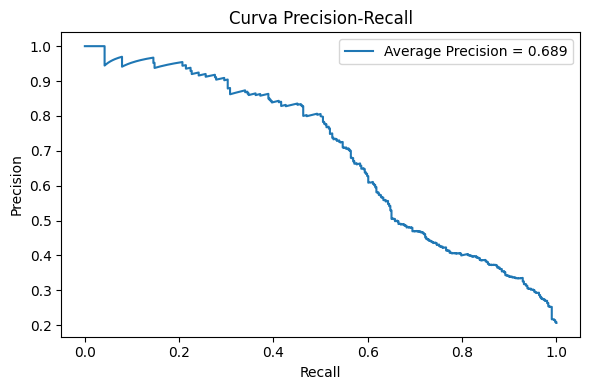

In [52]:
plot_roc_pr(y_test, y_prob)

In [53]:
funcion_costo = threshold_table(
    y_true=y_test,
    y_prob=y_prob,
    thresholds=thresholds,
    cost_fp=1,
    cost_fn=4
)

funcion_costo[[
    "threshold", "FP", "FN", "precision", "recall", "f1", "total_cost"
]].round(3)


,threshold,FP,FN,precision,recall,f1,total_cost
0,0.1,1403,4,0.223,0.990,0.364,1419
1,0.2,975,15,0.286,0.963,0.441,1035
2,0.3,691,44,0.344,0.892,0.496,867
3,0.4,521,68,0.393,0.833,0.534,793
4,0.5,335,115,0.465,0.717,0.564,795
5,0.6,48,208,0.805,0.488,0.607,880
6,0.7,24,258,0.860,0.365,0.512,1056
7,0.8,12,290,0.906,0.286,0.434,1172
8,0.9,4,327,0.952,0.195,0.323,1312


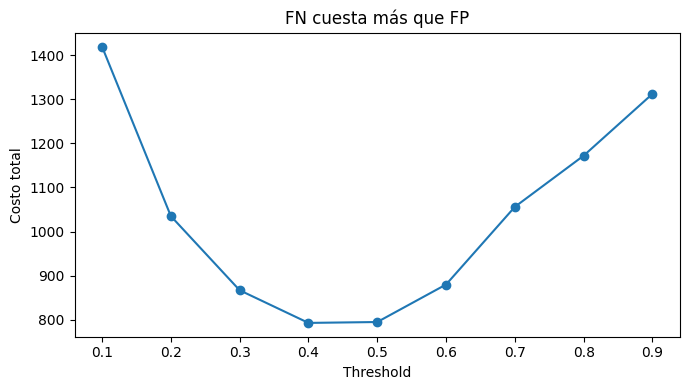

In [54]:
plot_cost_by_threshold(funcion_costo, title='FN cuesta más que FP')

In [55]:
y_val_pred=modelo.predict(X_val)
y_train_pred=modelo.predict(x_train)

train_acc = f1_score(y_train, y_train_pred)
val_acc = f1_score(y_val, y_val_pred)

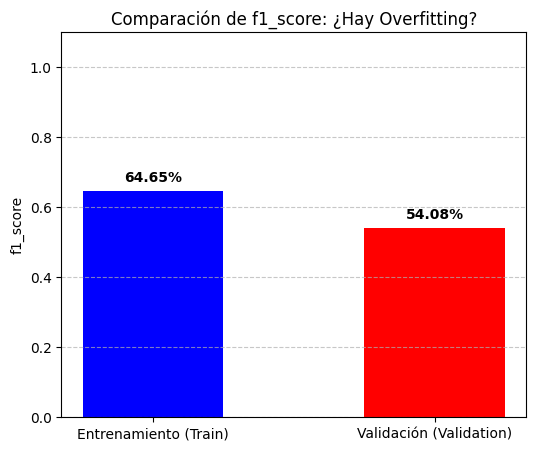

Brecha de rendimiento: 10.57%
Hay una brecha mayor al 10%


In [56]:
categorias = ["Entrenamiento (Train)", "Validación (Validation)"]
valores = [train_acc, val_acc]

plt.figure(figsize=(6, 5))
barras = plt.bar(categorias, valores, color=['blue', "red"], width=0.5)

for barra in barras:
    yval = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        yval + 0.02,
        f"{yval*100:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.ylabel("f1_score")
plt.title("Comparación de f1_score: ¿Hay Overfitting?")
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print(f"Brecha de rendimiento: {(train_acc - val_acc)*100:.2f}%")
if train_acc - val_acc > 0.10:
    print("Hay una brecha mayor al 10%")
else:
    print("La brecha es menor o igual al 10%")

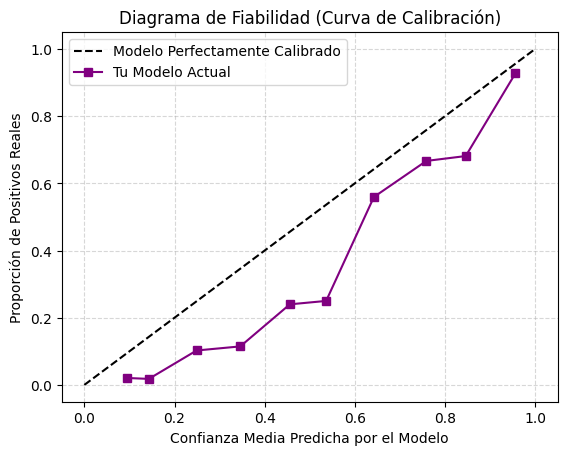

In [57]:
y_prob_val=modelo.predict_proba(X_val)[:,1]
prob_verdadera, prob_predicha = calibration_curve(
    y_val, y_prob_val, n_bins=10, strategy="uniform"
)
plt.plot([0, 1], [0, 1], "k--", label="Modelo Perfectamente Calibrado")

plt.plot(
    prob_predicha,
    prob_verdadera,
    "s-",
    color="purple",
    label="Tu Modelo Actual",
)

plt.title("Diagrama de Fiabilidad (Curva de Calibración)")
plt.xlabel("Confianza Media Predicha por el Modelo")
plt.ylabel("Proporción de Positivos Reales")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Regresión logística

In [58]:
from sklearn.linear_model import LogisticRegression


In [59]:
data_log=data.copy()

In [60]:
from sklearn.preprocessing import StandardScaler

In [61]:
x_log=data_log.drop(columns=['DESARMA_TARIMA'])
y_log=data_log['DESARMA_TARIMA']

In [62]:
X_temp, x_test, y_temp, y_test = train_test_split(
    x_log, y_log,
    test_size=0.20,
    stratify=y_log,
    random_state=RANDOM_STATE
)

x_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train:", x_train.shape)
print("Validation:", X_val.shape)
print("Test:", x_test.shape)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
X_val = scaler.transform(X_val)
x_test = scaler.transform(x_test)

parametros={
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'class_weight': ['balanced'],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [1000]
}

grid_srch=GridSearchCV(estimator=LogisticRegression(random_state=42),param_grid=parametros,return_train_score=True,n_jobs=-1)


Train: (5889, 10)
Validation: (1964, 10)
Test: (1964, 10)


In [63]:
grid_srch.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'class_weight': ['balanced'], 'max_iter': [1000], 'solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is di

In [64]:
print("Mejores hiperparámetros\n", grid_srch.best_params_)

Mejores hiperparámetros
 {'C': 0.001, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'lbfgs'}


In [65]:
modelo=grid_srch.best_estimator_

              precision    recall  f1-score   support

           0       0.89      0.70      0.78      1558
           1       0.37      0.67      0.47       406

    accuracy                           0.69      1964
   macro avg       0.63      0.68      0.63      1964
weighted avg       0.78      0.69      0.72      1964



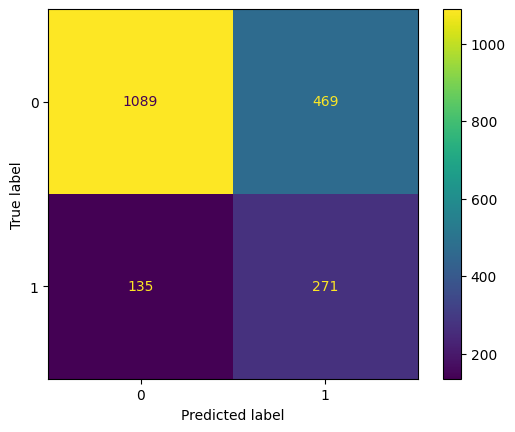

In [66]:
y_pred=modelo.predict(x_test)
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()
print(classification_report(y_test,y_pred))

<Figure size 640x480 with 0 Axes>

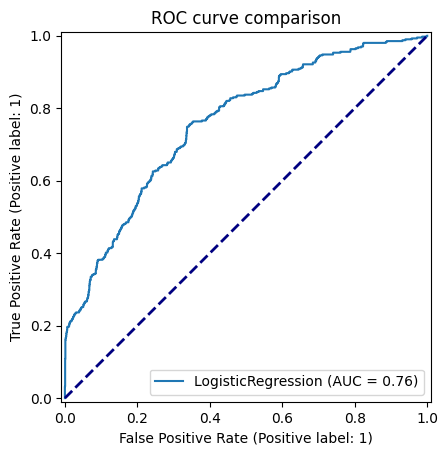

In [67]:
plt.figure()
lw = 2
disp = RocCurveDisplay.from_estimator(modelo, x_test, y_test)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.title("ROC curve comparison")
plt.legend(loc="lower right")
plt.show()

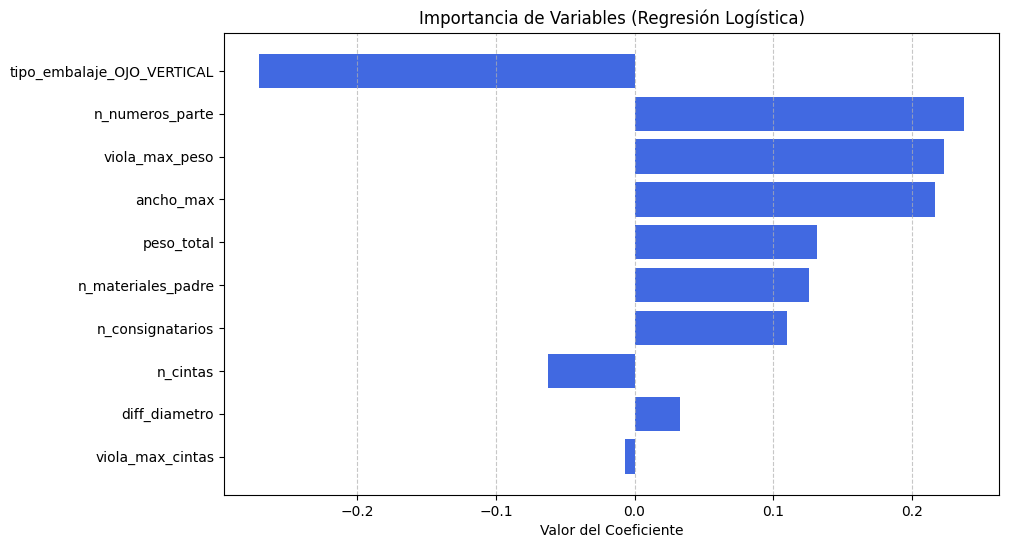

In [68]:
importancia = modelo.coef_[0]

df_importancia = pd.DataFrame({
    'Variable': x.columns,
    'Coeficiente': importancia,
    'Importancia_Absoluta': np.abs(importancia)
})

df_importancia = df_importancia.sort_values(by='Importancia_Absoluta', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Variable'], df_importancia['Coeficiente'], color='royalblue')
plt.gca().invert_yaxis()
plt.xlabel('Valor del Coeficiente')
plt.title('Importancia de Variables (Regresión Logística)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [69]:
y_prob = modelo.predict_proba(x_test)[:, 1]

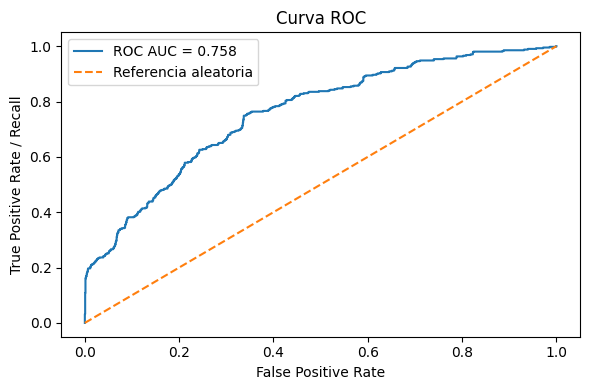

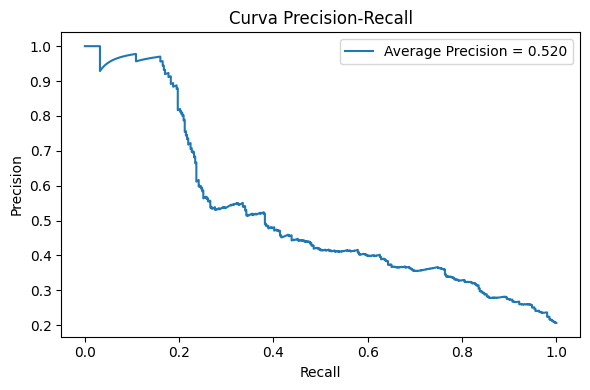

In [70]:
plot_roc_pr(y_test, y_prob)

In [71]:
funcion_costo = threshold_table(
    y_true=y_test,
    y_prob=y_prob,
    thresholds=thresholds,
    cost_fp=1,
    cost_fn=4
)

funcion_costo[[
    "threshold", "FP", "FN", "precision", "recall", "f1", "total_cost"
]].round(3)


,threshold,FP,FN,precision,recall,f1,total_cost
0,0.1,1558,0,0.207,1.000,0.343,1558
1,0.2,1558,0,0.207,1.000,0.343,1558
2,0.3,1014,37,0.267,0.909,0.413,1162
3,0.4,664,80,0.329,0.803,0.467,984
4,0.5,469,135,0.366,0.667,0.473,1009
5,0.6,180,243,0.475,0.401,0.435,1152
6,0.7,10,328,0.886,0.192,0.316,1322
7,0.8,3,339,0.957,0.165,0.282,1359
8,0.9,1,379,0.964,0.067,0.124,1517


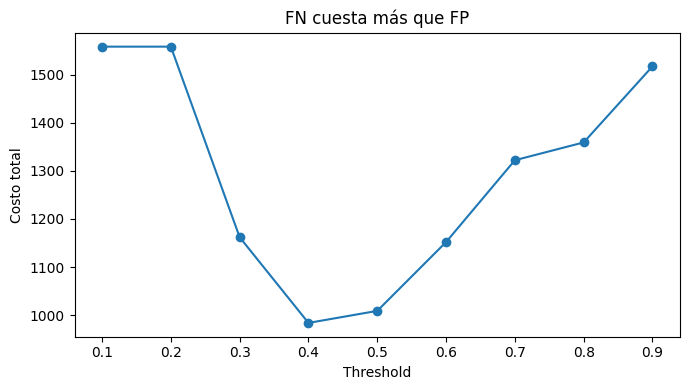

In [72]:
plot_cost_by_threshold(funcion_costo, title='FN cuesta más que FP')

In [73]:
y_val_pred=modelo.predict(X_val)
y_train_pred=modelo.predict(x_train)

train_acc = f1_score(y_train, y_train_pred)
val_acc = f1_score(y_val, y_val_pred)

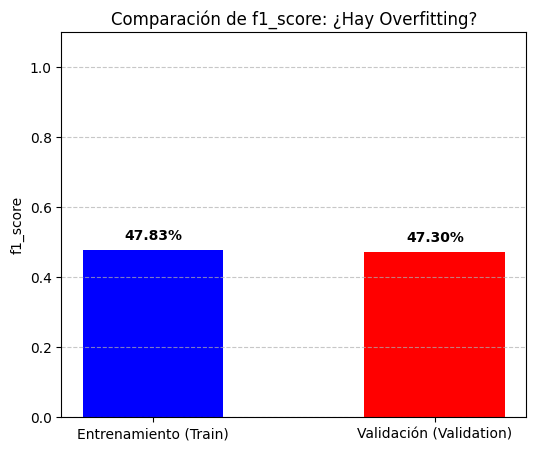

Brecha de rendimiento: 0.53%
La brecha es menor o igual al 10%


In [74]:
categorias = ["Entrenamiento (Train)", "Validación (Validation)"]
valores = [train_acc, val_acc]

plt.figure(figsize=(6, 5))
barras = plt.bar(categorias, valores, color=['blue', "red"], width=0.5)

for barra in barras:
    yval = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        yval + 0.02,
        f"{yval*100:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.ylabel("f1_score")
plt.title("Comparación de f1_score: ¿Hay Overfitting?")
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print(f"Brecha de rendimiento: {(train_acc - val_acc)*100:.2f}%")
if train_acc - val_acc > 0.10:
    print("Hay una brecha mayor al 10%")
else:
    print("La brecha es menor o igual al 10%")

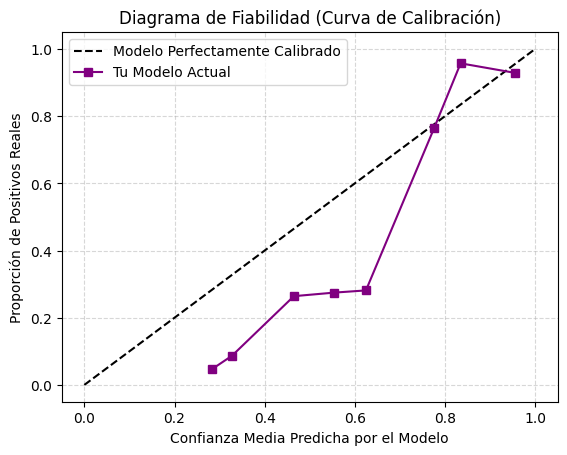

In [75]:
y_prob_val=modelo.predict_proba(X_val)[:,1]
prob_verdadera, prob_predicha = calibration_curve(
    y_val, y_prob_val, n_bins=10, strategy="uniform"
)
plt.plot([0, 1], [0, 1], "k--", label="Modelo Perfectamente Calibrado")

plt.plot(
    prob_predicha,
    prob_verdadera,
    "s-",
    color="purple",
    label="Tu Modelo Actual",
)

plt.title("Diagrama de Fiabilidad (Curva de Calibración)")
plt.xlabel("Confianza Media Predicha por el Modelo")
plt.ylabel("Proporción de Positivos Reales")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#XGboost

In [76]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [77]:
X_temp, x_test, y_temp, y_test = train_test_split(
    x, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

x_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train:", x_train.shape)
print("Validation:", X_val.shape)
print("Test:", x_test.shape)


xgb_model = XGBClassifier(
    scale_pos_weight=5,
    random_state=42
)

param_dist = {
    'n_estimators': [500],
    'learning_rate': [0.05,0.1, 0.15,],
    'max_depth': [3, 4,],
    'min_child_weight': [ 4, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'eval_metric': ['logloss'],
}

grd_srch = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_dist,
    scoring='f1',
     cv=3,
    n_jobs=-1
)

Train: (5889, 10)
Validation: (1964, 10)
Test: (1964, 10)


In [78]:
grd_srch.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.8, ...], 'eval_metric': ['logloss'], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [79]:
print("Mejores hiperparámetros\n", grd_srch.best_params_)

Mejores hiperparámetros
 {'colsample_bytree': 0.8, 'eval_metric': 'logloss', 'learning_rate': 0.15, 'max_depth': 4, 'min_child_weight': 4, 'n_estimators': 500, 'subsample': 0.7}


In [80]:
modelo=grd_srch.best_estimator_

              precision    recall  f1-score   support

           0       0.92      0.79      0.85      1558
           1       0.48      0.75      0.58       406

    accuracy                           0.78      1964
   macro avg       0.70      0.77      0.72      1964
weighted avg       0.83      0.78      0.79      1964



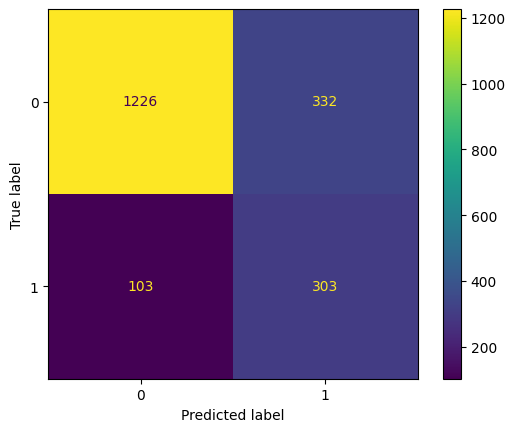

In [81]:
y_pred=modelo.predict(x_test)
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()
print(classification_report(y_test,y_pred))

<Figure size 640x480 with 0 Axes>

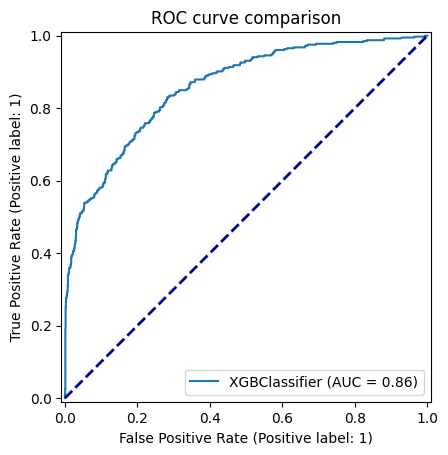

In [82]:
plt.figure()
lw = 2
disp = RocCurveDisplay.from_estimator(modelo, x_test, y_test)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.title("ROC curve comparison")
plt.legend(loc="lower right")
plt.show()

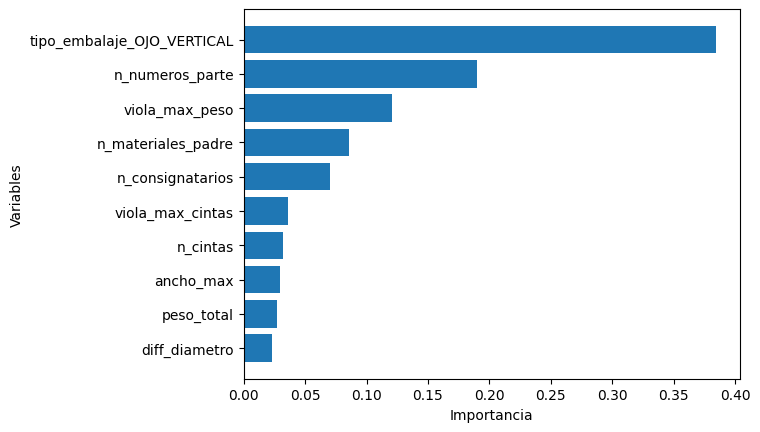

In [83]:
importancia=modelo.feature_importances_
importancia=pd.DataFrame(importancia,index=x.columns,columns=['importancia']).sort_values('importancia',ascending=True)
plt.barh(importancia.index,importancia['importancia'])
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.show()

In [84]:
y_prob = modelo.predict_proba(x_test)[:, 1]

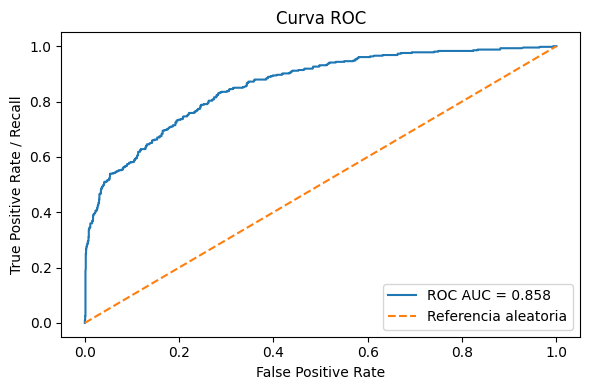

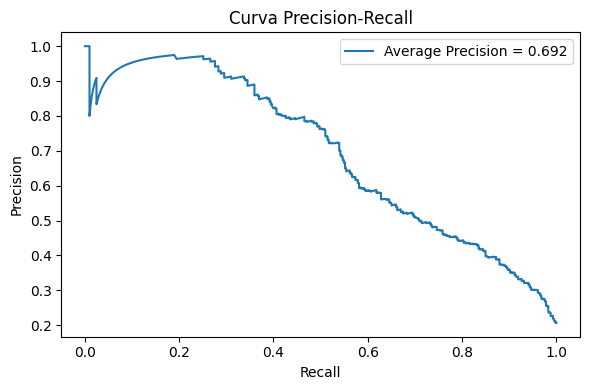

In [85]:
plot_roc_pr(y_test, y_prob)

In [86]:
funcion_costo = threshold_table(
    y_true=y_test,
    y_prob=y_prob,
    thresholds=thresholds,
    cost_fp=1,
    cost_fn=4
)

funcion_costo[[
    "threshold", "FP", "FN", "precision", "recall", "f1", "total_cost"
]].round(3)

,threshold,FP,FN,precision,recall,f1,total_cost
0,0.1,918,16,0.298,0.961,0.455,982
1,0.2,726,33,0.339,0.919,0.496,858
2,0.3,580,49,0.381,0.879,0.532,776
3,0.4,455,67,0.427,0.835,0.565,723
4,0.5,332,103,0.477,0.746,0.582,744
5,0.6,218,142,0.548,0.650,0.595,786
6,0.7,121,182,0.649,0.552,0.597,849
7,0.8,53,211,0.786,0.480,0.596,897
8,0.9,15,267,0.903,0.342,0.496,1083


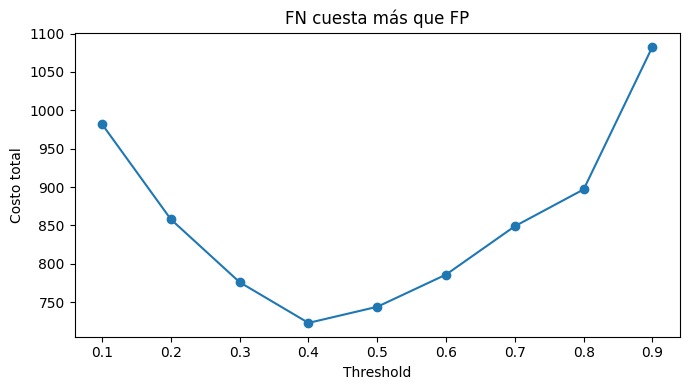

In [87]:
plot_cost_by_threshold(funcion_costo, title='FN cuesta más que FP')

In [88]:
y_val_pred=modelo.predict(X_val)
y_train_pred=modelo.predict(x_train)

train_acc = f1_score(y_train, y_train_pred)
val_acc = f1_score(y_val, y_val_pred)

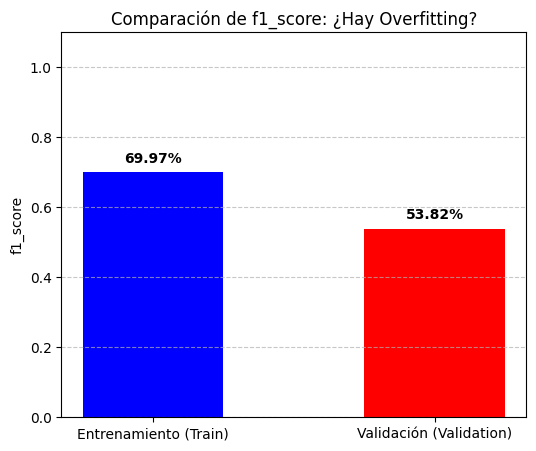

Brecha de rendimiento: 16.15%
Hay una brecha mayor al 10%


In [89]:
categorias = ["Entrenamiento (Train)", "Validación (Validation)"]
valores = [train_acc, val_acc]

plt.figure(figsize=(6, 5))
barras = plt.bar(categorias, valores, color=['blue', "red"], width=0.5)

for barra in barras:
    yval = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        yval + 0.02,
        f"{yval*100:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.ylabel("f1_score")
plt.title("Comparación de f1_score: ¿Hay Overfitting?")
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print(f"Brecha de rendimiento: {(train_acc - val_acc)*100:.2f}%")
if train_acc - val_acc > 0.10:
    print("Hay una brecha mayor al 10%")
else:
    print("La brecha es menor o igual al 10%")

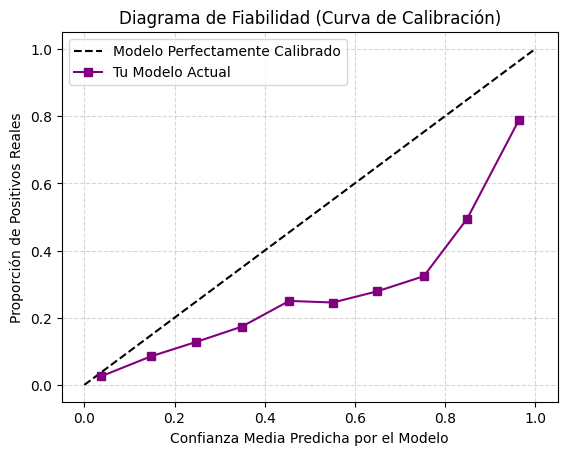

In [90]:
y_prob_val=modelo.predict_proba(X_val)[:,1]
prob_verdadera, prob_predicha = calibration_curve(
    y_val, y_prob_val, n_bins=10, strategy="uniform"
)
plt.plot([0, 1], [0, 1], "k--", label="Modelo Perfectamente Calibrado")

plt.plot(
    prob_predicha,
    prob_verdadera,
    "s-",
    color="purple",
    label="Tu Modelo Actual",
)

plt.title("Diagrama de Fiabilidad (Curva de Calibración)")
plt.xlabel("Confianza Media Predicha por el Modelo")
plt.ylabel("Proporción de Positivos Reales")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()